In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y
import pandas as pd
from planetmagfields import Planet

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

## Forward Model

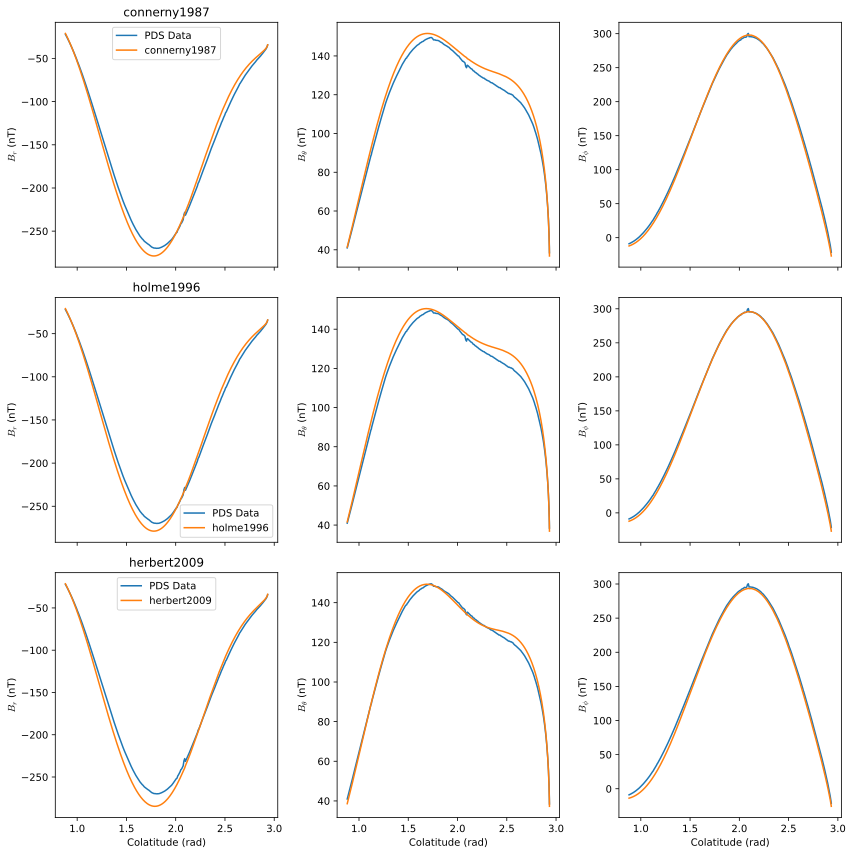

In [34]:
import os


df = pd.read_csv('./pds_data/uranus48s.csv')

theta = df['Colatitude'] * np.pi / 180
phi = (df['Longitude'] % 360) * np.pi / 180
r = df['Radius'].values

models = ['connerny1987', 'holme1996', 'herbert2009']

fig, ax = plt.subplots(nrows=len(models),ncols=3,figsize=(12,12), sharex=True)

for i, model in enumerate(models):
    pl = Planet(name='Uranus',model=model,info=False,unit='nT')
    pl.orbit_path(r,theta,phi)

    ax[i,0].plot(theta,df['Br'],label='PDS Data')
    ax[i,0].plot(theta,pl.br_orb,label=model)
    ax[i,1].plot(theta,df['Btheta'])
    ax[i,1].plot(theta,pl.btheta_orb)
    ax[i,2].plot(theta,df['Bphi'])
    ax[i,2].plot(theta,pl.bphi_orb)
    ax[i,0].set_title(model)
    ax[i,0].legend()
    ax[i,0].set_ylabel(r'$B_r$ (nT)')
    ax[i,1].set_ylabel(r'$B_\theta$ (nT)')
    ax[i,2].set_ylabel(r'$B_\phi$ (nT)')
ax[-1,0].set_xlabel('Colatitude (rad)')
ax[-1,1].set_xlabel('Colatitude (rad)')
ax[-1,2].set_xlabel('Colatitude (rad)')
fig.tight_layout()
os.makedirs('./plots', exist_ok=True)
plt.savefig('./plots/uranus_models.png',dpi=300)
plt.show()

## Inverse Modeling

### Plot Gauss coefficients from existing models

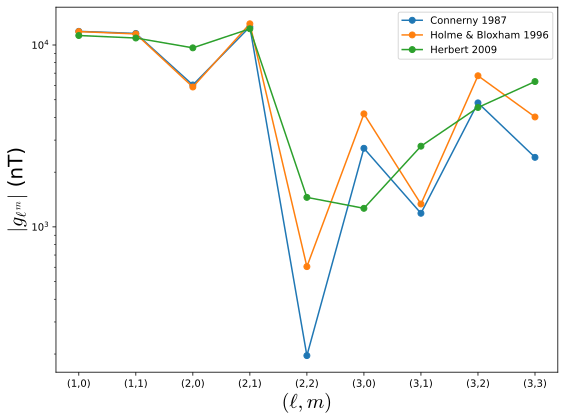

In [ ]:
# Plot Gauss coefficients
fig, ax = plt.subplots(figsize=(8,6))
for i, model in enumerate(models):
    pl = Planet(name='Uranus', model=model, info=False, unit='nT')
    if i == 0:
        label = 'Connerny 1987'
    elif i == 1:
        label = 'Holme & Bloxham 1996'
    elif i == 2:
        label = 'Herbert 2009'
    ax.plot(np.abs(pl.glm[1:10]),'-o',label=label)
ax.set_yscale('log')
ax.set_xlabel(r'$(\ell,m)$',fontsize=20)
ax.set_xticks(np.arange(9))
ax.set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_ylabel(r'$|g_{\ell^m}|$ (nT)',fontsize=20)
ax.legend()
fig.tight_layout()
# plt.savefig('./plots/uranus_gauss_coefficients.png',dpi=300)

plt.show()

In [72]:
from scipy.linalg import block_diag

class InverseModel:
    def __init__(self, lmax, r, theta, phi, br, btheta, bphi, sigma=0.5, Bpsi=0.36):
        self.lmax = lmax
        self.r = r
        self.theta = theta
        self.phi = phi
        self.br = br
        self.btheta = btheta
        self.bphi = bphi
        self.npoints = len(r)

        count = 0
        idx = np.zeros((lmax+1, lmax+1), dtype=int)
        for l in range(lmax+1):
            for m in range(l+1):
                idx[l, m] = count
                count += 1

        self.idx = idx
        self.ncoeffs = count
        self.A = np.zeros((3*self.npoints, count), dtype=complex)

        for i in range(self.npoints):
            for l in range(lmax+1):
                for m in range(l+1):
                    ylm = sph_harm_y(l,m,theta[i],phi[i],diff_n=1)
                    dylmdth = ylm[1][...,0]
                    dylmdphi = ylm[1][...,1]
                    ylm = ylm[0]
                    if m == 0:
                        Nlm = np.sqrt(4 * np.pi / (2*l+1))
                    else:
                        Nlm = np.sqrt(8 * np.pi / (2*l+1)) * (-1)**m
                    self.A[i, self.idx[l, m]] = (self.r[i]**-(l+2)) * (l+1) * Nlm * ylm #Br
                    self.A[self.npoints+i, self.idx[l, m]] = (self.r[i]**-(l+2)) * Nlm * dylmdth #Btheta
                    self.A[2*self.npoints+i, self.idx[l, m]] = (self.r[i]**-(l+2)) * Nlm * dylmdphi / np.sin(self.theta[i]) #Bphi

        self.b = np.concatenate([self.br, self.btheta, self.bphi])

        #Setup inverse of data covariance matrix: Ce_inv = (I sigma^2 + BB^T\psi^2)/(\sigma^2(\sigma^2 + B^2\psi^2)))
        # self.Ce_inv = self.build_Ce_inv(sigma, Bpsi)

    def _build_Ce_inv(self, sigma, Bpsi):
        """Build block-diagonal Ce_inv using matrix operations."""
        N = self.npoints
        sigma2 = sigma**2
        Bpsi2 = Bpsi**2

        B = np.column_stack([self.br, self.btheta, self.bphi])
        B2 = np.sum(B**2, axis=1)
        psi2 = np.where(B2 > 1e-10, Bpsi2 / B2, 0.0)
        denom = sigma2 * (sigma2 + Bpsi2)

        I3 = np.eye(3)
        term1 = sigma2 * I3[np.newaxis, :, :]
        term2 = psi2[:, np.newaxis, np.newaxis] * (B[:, :, np.newaxis] @ B[:, np.newaxis, :])
        blocks = (term1 + term2) / denom

        return block_diag(*blocks)

    def get_lambda(self, smoothing_norm='Br2', r=1.0):

            Lmbda = np.zeros((self.ncoeffs, self.ncoeffs))

            for l in range(1, self.lmax+1):
                for m in range(l+1):
                    idx = self.idx[l, m]

                    if smoothing_norm == 'B2':
                        # Norm (a): mean field strength at r
                        Lmbda[idx, idx] = (l + 1) * (1.0/r)**(2*l + 4)

                    elif smoothing_norm == 'Br2':
                        # Norm (b): mean square Br at r
                        Lmbda[idx, idx] = (l + 1)**2 / (2*l + 1) * (1.0/r)**(2*l + 4)

                    elif smoothing_norm == 'dBr2':
                        # Norm (c): horizontal derivative of Br at r
                        Lmbda[idx, idx] = l * (l + 1)**3 / (2*l + 1) * (1.0/r)**(2*l + 6)

                    elif smoothing_norm == 'energy':
                        # Norm (d): magnetostatic energy outside r
                        Lmbda[idx, idx] = (l + 1) / (2*l + 1) * (1.0/r)**(2*l + 1)

                    else:
                        # Simple Tikhonov (identity)
                        Lmbda[idx, idx] = 1.0

            return Lmbda

    def solve(self, alpha=0.0, smoothing_norm='Br2', r=1):
        n = self.A.shape[1]

        self.Ce_inv = self._build_Ce_inv(sigma=0.5, Bpsi=0.36)
        self.Lmbda = self.get_lambda(smoothing_norm=smoothing_norm,r=r)
        AtCeA = self.A.conj().T @ self.Ce_inv @ self.A
        AtCeb = self.A.conj().T @ self.Ce_inv @ self.b

        LHS = AtCeA + alpha * self.Lmbda
        self.pol = np.linalg.solve(LHS, AtCeb)

        glm = np.real(self.pol)
        hlm = -np.imag(self.pol)

        residuals = self.b - self.A @ self.pol
        self.misfit = np.real(residuals.conj().T @ self.Ce_inv @ residuals)

        return glm, hlm

    def trade_off_curve(self, alpha_arr, smoothing_norm='Br2', r=1):
        misfits = []
        norms = []
        for alpha in alpha_arr:
            glm, hlm = self.solve(alpha=alpha, smoothing_norm=smoothing_norm, r=r)
            misfits.append(self.misfit)
            norm = np.real(self.pol.conj().T @ self.Lmbda @ self.pol)
            norms.append(norm)
        return np.array(misfits), np.array(norms)



[1.00000000e-04 1.93069773e-04 3.72759372e-04 7.19685673e-04
 1.38949549e-03 2.68269580e-03 5.17947468e-03 1.00000000e-02
 1.93069773e-02 3.72759372e-02 7.19685673e-02 1.38949549e-01
 2.68269580e-01 5.17947468e-01 1.00000000e+00 1.93069773e+00
 3.72759372e+00 7.19685673e+00 1.38949549e+01 2.68269580e+01
 5.17947468e+01 1.00000000e+02 1.93069773e+02 3.72759372e+02
 7.19685673e+02 1.38949549e+03 2.68269580e+03 5.17947468e+03
 1.00000000e+04 1.93069773e+04 3.72759372e+04 7.19685673e+04
 1.38949549e+05 2.68269580e+05 5.17947468e+05 1.00000000e+06
 1.93069773e+06 3.72759372e+06 7.19685673e+06 1.38949549e+07
 2.68269580e+07 5.17947468e+07 1.00000000e+08 1.93069773e+08
 3.72759372e+08 7.19685673e+08 1.38949549e+09 2.68269580e+09
 5.17947468e+09 1.00000000e+10]


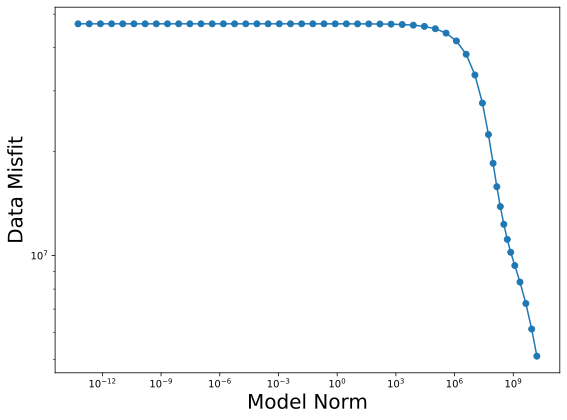

In [80]:
M = InverseModel(lmax=3, r=r, theta=theta, phi=phi, br=df['Br'].values, btheta=df['Btheta'].values, bphi=df['Bphi'].values)

# Plot trade-off curve
fig, ax = plt.subplots(figsize=(8,6))
alpha_arr = np.logspace(-4, 10, 50)
print(alpha_arr)
misfits, norms = M.trade_off_curve(alpha_arr, smoothing_norm='energy', r=1)
ax.loglog(norms, misfits, '-o')
ax.set_xlabel('Model Norm', fontsize=20)
ax.set_ylabel('Data Misfit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
# plt.savefig('./plots/uranus_tradeoff_curve.png',dpi=300)
plt.show()

# pl = Planet(name='Uranus', model='connerny1987', info=False, unit='nT')

# fig, ax = plt.subplots(figsize=(8,6))
# ax.plot(np.abs(glm[1:10]),'-o',label='Fitted Model')
# ax.plot(np.abs(pl.glm[1:10]),'-o',label='Connerny 1987')
# ax.set_yscale('log')
# ax.set_xlabel(r'$(\ell,m)$',fontsize=20)
# ax.set_xticks(np.arange(9))
# ax.set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
# ax.tick_params(axis='both', which='major', labelsize=10)
# ax.set_ylabel(r'$|g_{\ell^m}|$ (nT)',fontsize=20)
# ax.legend()
# fig.tight_layout()
# # plt.savefig('./plots/uranus_fitted_gauss_coefficients.png',dpi=300)
# plt.show()

In [81]:
alpha_arr[34]

517947.4679231202

In [100]:
glm, hlm = M.solve(alpha=5e-3, smoothing_norm='energy', r=1)

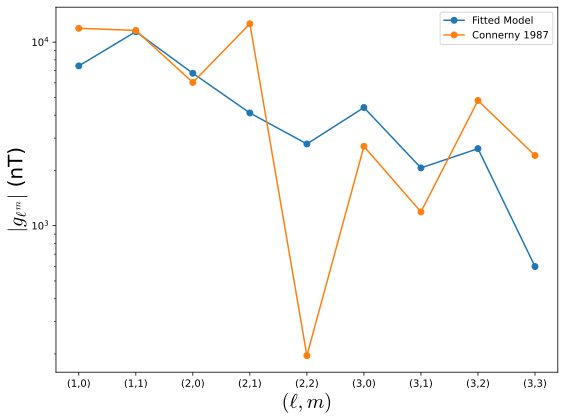

In [101]:
pl = Planet(name='Uranus', model='connerny1987', info=False, unit='nT')

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(np.abs(glm[1:10]),'-o',label='Fitted Model')
ax.plot(np.abs(pl.glm[1:10]),'-o',label='Connerny 1987')
ax.set_yscale('log')
ax.set_xlabel(r'$(\ell,m)$',fontsize=20)
ax.set_xticks(np.arange(9))
ax.set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_ylabel(r'$|g_{\ell^m}|$ (nT)',fontsize=20)
ax.legend()
fig.tight_layout()
# plt.savefig('./plots/uranus_fitted_gauss_coefficients.png',dpi=300)
plt.show()